In [23]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 500

temperature = np.random.randint(120, 251, n)
pressure = np.random.randint(40, 121, n)
purity = np.round(np.random.uniform(70, 100, n), 2)
speed = np.random.randint(150, 501, n)

noise = np.random.normal(0, 0.45, n)

quality = (
    0.020 * temperature
    + 0.018 * pressure
    + 0.060 * purity
    - 0.010 * speed
    + noise
)

# Scale target to 1-10
quality = 1 + (quality - quality.min()) * 9 / (quality.max() - quality.min())
quality = np.round(quality, 2)

df = pd.DataFrame({
    "temperature": temperature,
    "pressure": pressure,
    "purity": purity,
    "speed": speed,
    "quality_score": quality
})

df.to_csv("product_quality_linear_regression.csv", index=False)

print(df.head())
print(df.shape)

   temperature  pressure  purity  speed  quality_score
0          222       104   91.12    353           6.27
1          212        57   97.32    314           5.85
2          134        88   88.74    454           4.20
3          226        50   80.08    269           6.06
4          191        65   94.75    193           7.15
(500, 5)


x = [temerature, pressure, purity, speed]<br>
y = quality_score

## Simple linear regression

If you have one input column/feature(x) along with y

In [24]:
X = df[['temperature']]#x always will be 2 dimension
y = df['quality_score']#y always will be 1 dimnension

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Train test split

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
model = LinearRegression()

model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
y_pred = model.predict(X_test)

In [29]:
print("score: ",round(r2_score(y_test,y_pred)*100,3),"%")

score:  35.207 %


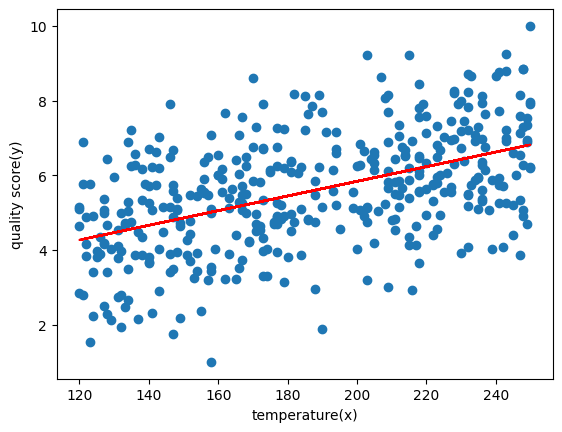

In [30]:
import matplotlib.pyplot as plt

plt.scatter(X_train,y_train)
plt.plot(X_test,y_pred,c='red')
plt.xlabel("temperature(x)")
plt.ylabel("quality score(y)")
plt.show()

## Multiple linear regression

the regression where we use more than one feature columns(x) and y always will be 1

In [31]:
df.head()

,temperature,pressure,purity,speed,quality_score
0,222,104,91.12,353,6.27
1,212,57,97.32,314,5.85
2,134,88,88.74,454,4.20
3,226,50,80.08,269,6.06
4,191,65,94.75,193,7.15


In [32]:
X = df.drop('quality_score',axis=1)
y = df['quality_score']

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [34]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
y_pred = model.predict(X_test)

In [36]:
print("score: ",round(r2_score(y_test,y_pred)*100,3),"%")

score:  86.758 %
